<a href="https://colab.research.google.com/github/hynekmayrhofer1/Hynek-Mayrhofer/blob/main/Funkce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Funkce - [pyladies](https://naucse.python.cz/2020/pyladies-hradec-leden/beginners/def/)

*args a **kwargs v Pythonu umožňují funkci přijímat libovolný počet pozičních a klíčových argumentů. *args shromažďuje všechny nepojmenované (poziční) argumenty do n-tice (tuple), zatímco **kwargs sbírá pojmenované (klíčové) argumenty do slovníku. To umožňuje větší flexibilitu při definování a volání funkcí, které nepotřebují mít předem daný počet argumentů.

### *args (poziční argumenty)

Zachytí libovolný počet pozičních argumentů, které nejsou explicitně definovány v seznamu parametrů funkce.
Předá tyto argumenty jako n-tici (tuple), na kterou lze přistupovat pomocí indexů.

### **kwargs (klíčové argumenty)
Zachytí všechny nepředané klíčové argumenty do slovníku, kde klíče jsou názvy argumentů a hodnoty jsou jejich přiřazené hodnoty.

Využití - flexibilní funkce s volitelným množstvím parametrů, [dekorátory funkce](https://www.itnetwork.cz/python/oop/dekoratory-v-pythonu).

S pomocí generativního AI chatbotu ([Claude](https://claude.ai/new)), [GitHub Copilot](https://github.com/copilot), ChatGPT, [Gemini](https://gemini.google.com/app) ) vylepši.

In [15]:
def prumer(*cisla):
    """Vrátí průměr zadaných čísel. Ignoruje nečíselné hodnoty."""

    # Pokud je průměr volán bez argumentů → nic k výpočtu
    if len(cisla) == 0:
        print("Nebyla zadána žádná čísla.")
        return None

    # Vyfiltrujeme jen čísla
    numericka = [x for x in cisla if isinstance(x, (int, float))]

    if len(numericka) == 0:
        print("Nebyla zadána žádná číselná hodnota.")
        return None

    # Debug info
    print("Původní data:", cisla)
    print("Číselné hodnoty:", numericka)
    print("Počet čísel:", len(numericka))
    print("Poslední dvě hodnoty:", numericka[-2:] if len(numericka) >= 2 else numericka)

    return sum(numericka) / len(numericka)

#print(prumer(1, 2, 3, 4)) # 2.5
print(prumer(1, 2, 3, 4))


Původní data: (1, 2, 3, 4)
Číselné hodnoty: [1, 2, 3, 4]
Počet čísel: 4
Poslední dvě hodnoty: [3, 4]
2.5


Vyzkoušejte různé typy volání funkce

In [ ]:
text = []

In [25]:
def vypis(text, *text2, opakovani=1):
  for _ in range(opakovani):
    print(text, end = ", ")
    print(text2)


vypis("Ahoj")
vypis("Helo", "Hm", "Neco dalsiho", opakovani = 3)
vypis("Tohle je spravne volani", opakovani = 2)

Ahoj, ()
Helo, ('Hm', 'Neco dalsiho')
Helo, ('Hm', 'Neco dalsiho')
Helo, ('Hm', 'Neco dalsiho')
Tohle je spravne volani, ()
Tohle je spravne volani, ()


Vysvětli kód

In [28]:
def vypis(text:str, *text2:str, opakovani=1):
    '''
    Vypíše hlavní text a cyklicky opakuje doplňkové texty.
    Pokud nejsou doplňkové texty zadány, vypíše prázdný řádek.
    '''
    for _ in range(opakovani):
        print(text, end = ", ")
        if text2:
            index = _ % len(text2)
            print(text2[index])  # vypíše položku texty2
        else:
            print() # Vypíše prázdný řádek, pokud text2 je prázdné
vypis("Hello", "Pravni", "Druhy", opakovani = 5)
# Příklad volání, které by dříve způsobilo chybu:
vypis("Ahoj", opakovani = 3)


Hello, Pravni
Hello, Druhy
Hello, Pravni
Hello, Druhy
Hello, Pravni
Ahoj, 
Ahoj, 
Ahoj, 


In [4]:
def vypis_info(**kwargs):
  for klic, hodnota in kwargs.items():
    print(f"{klic}: {hodnota}")

vypis_info(jmeno="Petr", vek=30, mesto="Praha")

jmeno: Petr
vek: 30
mesto: Praha


Pořadí musí být:
poziční → *args → pojmenované → **kwargs

Vykoušejte různé způsoby volání funkcí

In [27]:
def mix(a, b, *args, c=0, **kwargs):
    print("a =", a)
    print("b =", b)
    print("args =", args)
    print("c =", c)
    print('kwargs =', kwargs)

mix(1, 2, 3, 4, 5, c=10, x=100, y=200)

a = 1
b = 2
args = (3, 4, 5)
c = 10
kwargs = {'x': 100, 'y': 200}


### Chybová hlášení
Ošetřete dělení nulou nějakým jiným způsobem.

In [29]:
def deleni(a:float, b:float):
    if b == 0:
        raise ValueError("Nulou nelze dělit!")
    return a / b

print(deleni(10, 0))

2.0


Typové hinty, isinstance
Když Python narazí na raise, okamžitě zastaví program a ukáže chybovou hlášku.

Nejčastější chybové hlášky:
raise TypeError("Očekávám číslo, ale dostal jsem text.")
raise ValueError("Číslo musí být kladné.")
raise IndexError("Index je mimo rozsah seznamu.")
raise RuntimeError("Došlo k neočekávané chybě.")

In [30]:
def obsah(a: int, b: int) -> float:
    return a*b
S = obsah(2,"3")
print(S)

33


In [31]:
def obsah(a: int, b: int) -> int:
    if not (isinstance(a, int) and isinstance(b,int)) :
        raise TypeError("Argumenty 'a, b' musí být typu int.")
    return a*b
S = obsah(2,"3")
print(S)

TypeError: Argumenty 'a, b' musí být typu int.

### Generování náhodných čísel

In [32]:
import random

print(random.randint(1, 10))     # celé číslo 1–10
print(random.random())           # číslo 0–1
print(random.uniform(5, 15))     # desetinné číslo 5–15

5
0.05603079650006715
10.924468682297826


Vylepšete funkci  nahodny_prumer (docstring, typové hinty, *args, klíčové parametry)

In [35]:
def nahodny_prumer(n):
    cisla = [random.randint(1, 100) for _ in range(n)]
    return sum(cisla) / n

print(nahodny_prumer(98))

52.775510204081634


Vygenerujte náhodná čísla a zobrazte jejich histogram = sloupcový graf, který ukazuje, kolikrát se něco vyskytuje.

Vygenerovaná čísla:
[ 2.43042616  0.51791559 -2.07891457  1.05600097  0.51865975 -1.18738053
  2.432451   -0.06972075  0.41896717 -1.35283536 -0.62331487  1.29282608
 -0.55877573  0.79059586 -0.22448158 -0.68632336 -0.80877822  0.87436982
  1.17892486  0.50805588  1.51957637 -0.9139453  -0.27200478 -0.29016484
  0.53481908 -0.17205495  0.40337218 -1.23592127  0.37576924 -2.84365717
 -0.02157743 -0.19058267 -2.06475115 -0.40976698  1.2353984  -0.43680617
 -0.98610369  0.03268717 -0.86394765 -1.40316647 -0.14820463 -0.30965344
 -0.26006426 -0.84739403 -0.91657262 -1.53247741  0.42452214 -0.84210046
 -0.78315959  0.58927406  0.06784797 -1.88999853  0.4900781   2.26462488
 -0.22358156  0.20887234 -1.14399872 -1.09319899 -1.39527596 -1.51229338
  0.55597461 -1.25357942 -1.18227443  0.46159053 -1.2781561   0.39596987
  0.64858047 -0.09985814  0.46686938 -0.11165859  2.49204673 -0.52962438
 -1.97479794  0.62589248  0.33526696  1.96886888 -0.16273622 -0.29503736
 -1.22666083  2.15644426 -0.973

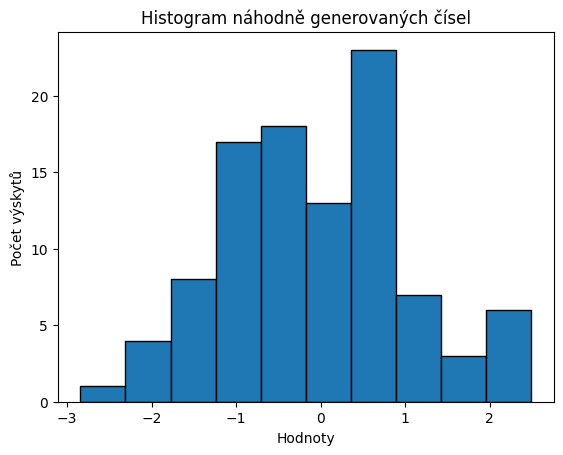

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Vygenerujeme 100 náhodných čísel (normální rozdělení)
data = np.random.randn(100)

print("Vygenerovaná čísla:")
print(data)

# Histogram
plt.hist(data, bins=10, edgecolor='black')
plt.title("Histogram náhodně generovaných čísel")
plt.xlabel("Hodnoty")
plt.ylabel("Počet výskytů")
plt.show()
